# Import Library

In [1]:
import numpy as np
import matplotlib as plt
import seaborn as sns
import requests
import pandas as pd
from bs4 import BeautifulSoup
import openpyxl

# Scrapping Website CoinMarketCap

In [2]:
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
import requests
import pandas as pd
from bs4 import BeautifulSoup


def scrape():
    url = 'https://coinmarketcap.com/gainers-losers/'
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) ...'
    }
    try:
        response = requests.get(url, headers=headers)
    except Exception as e:
        print(f"Koneksi gagal: {e}")
        return [], []

    if response.status_code != 200:
        print(f'Error: {response.status_code}')
        return [], []

    soup = BeautifulSoup(response.text, 'html.parser')
    tables = soup.findAll('table', class_='cmc-table')

    if len(tables) < 2:
        print("Tabel tidak ditemukan (kemungkinan konten di-render oleh JS).")
        return [], []

    def parse_table(target_table):
        data = []
        rows = target_table.findAll('tr')[1:]
        for row in rows:
            cols = row.findAll('td')
            if len(cols) >= 5:  # ✅ minimal 5 kolom
                data.append({
                    "Name": cols[1].text.strip(),
                    "Price": cols[2].text.strip(),
                    "24h Change": cols[3].text.strip(),
                    "Volume(24h)": cols[4].text.strip()
                })
        return data

    return parse_table(tables[0]), parse_table(tables[1])

gainers, losers = scrape()

if gainers or losers:
    df_gainers = pd.DataFrame(gainers)
    df_gainers.to_excel("gainers.xlsx", index=False)  # ✅ index=False

    df_losers = pd.DataFrame(losers)
    df_losers.to_excel("losers.xlsx", index=False)

C:\Users\Asus\AppData\Local\Temp\ipykernel_24980\2900036570.py:25: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  tables = soup.findAll('table', class_='cmc-table')
C:\Users\Asus\AppData\Local\Temp\ipykernel_24980\2900036570.py:33: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  rows = target_table.findAll('tr')[1:]
C:\Users\Asus\AppData\Local\Temp\ipykernel_24980\2900036570.py:35: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  cols = row.findAll('td')


# DataFrame Gainners Coin

In [3]:
gainners = pd.read_excel("gainers.xlsx")
dataframe_gainners = pd.DataFrame(gainners)
dataframe_gainners.head(10)

,Name,Price,24h Change,Volume(24h)
0,edgeX83EDGE,$1.35,16.24%,"$50,504,723"
1,币安人生88币安人生,$0.4397,11.36%,"$134,452,521"
2,siren80SIREN,$0.7056,9.98%,"$22,413,558"
3,Chiliz86CHZ,$0.04344,8.47%,"$95,299,665"
4,Sky39SKY,$0.07922,4.43%,"$15,942,209"
5,Canton16CC,$0.152,2.88%,"$13,241,816"
6,JUST70JST,$0.07391,2.59%,"$34,025,937"
7,Polygon (prev. MATIC)56POL,$0.09032,1.47%,"$58,278,294"
8,Pudgy Penguins85PENGU,$0.007224,1.27%,"$112,948,067"
9,Bonk79BONK,$0.056059,1.17%,"$67,881,564"


# DataFrame Lossers Coin

In [4]:
loserss = pd.read_excel("losers.xlsx")
dataframe_losers = pd.DataFrame(loserss)
dataframe_losers.head(10)

,Name,Price,24h Change,Volume(24h)
0,Hyperliquid10HYPE,$40.86,5.71%,"$346,377,139"
1,Mantle38MNT,$0.6221,4.71%,"$1,741,292,640"
2,Monad97MON,$0.03064,4.60%,"$88,575,583"
3,Zcash20ZEC,$309.80,4.05%,"$632,371,164"
4,Jupiter72JUP,$0.1701,4.05%,"$24,386,906"
5,ether.fi96ETHFI,$0.4567,3.96%,"$25,948,171"
6,Celestia98TIA,$0.385,3.88%,"$52,558,916"
7,Artificial Superintelligence Alliance84FET,$0.2076,3.32%,"$144,037,395"
8,Midnight75NIGHT,$0.03574,3.25%,"$21,837,352"
9,LayerZero81ZRO,$1.57,3.02%,"$128,746,729"


# Check Missing Value Gainners

In [5]:
df_gainers.isnull().sum()

Name           0
Price          0
24h Change     0
Volume(24h)    0
dtype: int64

# Check Missing Value Lossers

In [6]:
df_losers.isnull().sum()

Name           0
Price          0
24h Change     0
Volume(24h)    0
dtype: int64

# Data Cleaning Gainners & Lossers

In [7]:
for df in [df_gainers, df_losers]:
    df['Price'] = df['Price'].str.replace('$', '', regex=False).str.replace(',', '').astype(float)
    df['24h Change'] = df['24h Change'].str.replace('%', '', regex=False).astype(float)
    df['Volume(24h)'] = df['Volume(24h)'].str.replace('$', '', regex=False).str.replace(',', '').astype(float)

df_gainers.head()

,Name,Price,24h Change,Volume(24h)
0,edgeX83EDGE,1.35000,16.24,50504723.0
1,币安人生88币安人生,0.43970,11.36,134452521.0
2,siren80SIREN,0.70560,9.98,22413558.0
3,Chiliz86CHZ,0.04344,8.47,95299665.0
4,Sky39SKY,0.07922,4.43,15942209.0


# Check Outlier Gainners

In [8]:
Q1 = df_gainers['Price'].quantile(0.25)
Q3 = df_gainers['Price'].quantile(0.75)
IQR = Q3 - Q1  

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_iqr = df_gainers[
    (df_gainers['Price'] < lower) | (df_gainers['Price'] > upper)
]

print('Jumlah outlier dari gainers: ', len(outlier_iqr))

Jumlah outlier dari gainers:  3


# Check Outlier Lossers

In [9]:
Q1 = df_losers['Price'].quantile(0.25)
Q3 = df_losers['Price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

qutlier_iqr = df_losers[
    (df_losers['Price'] < lower) | (df_losers['Price'] > upper)
]

print('Jumlah outlier dari losers: ', len(qutlier_iqr))

Jumlah outlier dari losers:  6


# Handling Outlier Gainners

In [10]:
data_iqr_clean_gainners = df_gainers[
    (df_gainers['Price'] >= lower) & (df_gainers['Price'] <= upper)
]

print("Jumlah data yang bersih: ", len(data_iqr_clean_gainners))

Jumlah data yang bersih:  21


# EDA Gainners

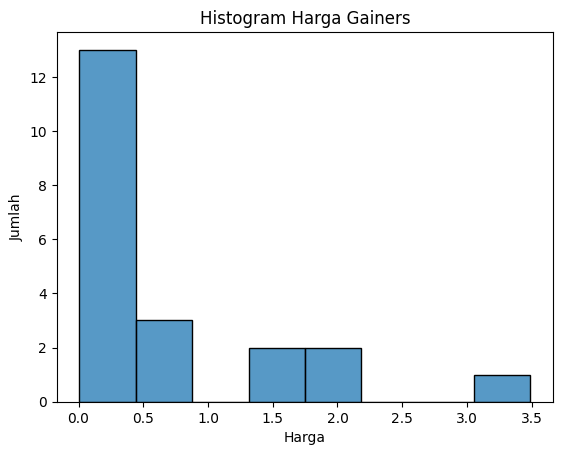

In [11]:
import matplotlib.pyplot as plt
sns.histplot(data=data_iqr_clean_gainners[data_iqr_clean_gainners['Price'] <  20000], x='Price')
plt.xlabel('Harga')
plt.ylabel('Jumlah')
plt.title('Histogram Harga Gainers')
plt.show()

# Handling Outlier Lossers

In [12]:
data_iqr_clean_lossers = df_losers[
    (df_losers['Price'] >= lower) & (df_losers['Price'] <= upper)
]

print("Jumlah data yang bersih: ", len(data_iqr_clean_lossers))

Jumlah data yang bersih:  24


# EDA lossers

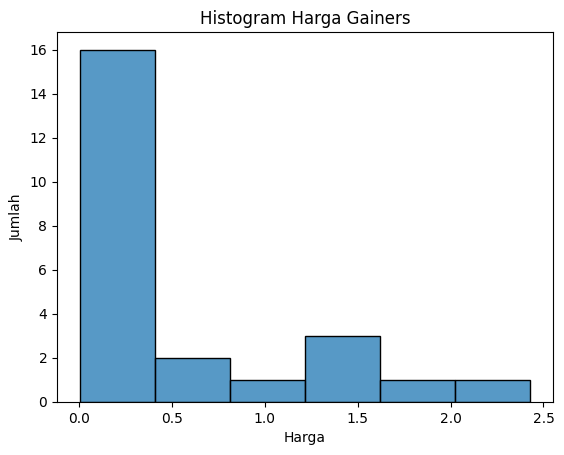

In [13]:
import matplotlib.pyplot as plt
sns.histplot(data=data_iqr_clean_lossers[data_iqr_clean_lossers['Price'] <  20000], x='Price')
plt.xlabel('Harga')
plt.ylabel('Jumlah')
plt.title('Histogram Harga Gainers')
plt.show()